<a href="https://colab.research.google.com/github/Tanishq7361/Coupled-Oscillators-and-Nonlinear-Pendulum/blob/main/Coupled_Oscillators_and_Nonlinear_Pendulum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coupled Oscillators and Nonlinear Pendulum Dynamics

## Q1. Coupled Oscillators

Two masses connected by three springs (wall–$m_1$–$m_2$–wall):
$$m_1\ddot{x}_1 = -(k_1 + k_2)x_1 + k_2 x_2$$
$$m_2\ddot{x}_2 = k_2 x_1 - (k_2 + k_3)x_2$$

Reduce to a first-order system with $v_1 = \dot{x}_1$, $v_2 = \dot{x}_2$:
$$\dot{x}_1 = v_1, \quad \dot{v}_1 = \frac{-(k_1+k_2)x_1 + k_2 x_2}{m_1}$$
$$\dot{x}_2 = v_2, \quad \dot{v}_2 = \frac{k_2 x_1 - (k_2+k_3)x_2}{m_2}$$

**Initial conditions:** $x_1(0) = 1$, $x_2(0) = 0$, $v_1(0) = v_2(0) = 0$ (only mass 1 displaced).

Solved using `scipy.integrate.solve_ivp` with RK45.

---

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

def coupled_rhs(t, state, m1, m2, k1, k2, k3):
    x1, x2, v1, v2 = state
    a1 = (-(k1 + k2)*x1 + k2*x2) / m1
    a2 = (k2*x1 - (k2 + k3)*x2) / m2
    return [v1, v2, a1, a2]

def solve_coupled(m1, m2, k1, k2, k3, t_end=60, n_pts=10000,
                  x1_0=1.0, x2_0=0.0, v1_0=0.0, v2_0=0.0):
    t_eval = np.linspace(0, t_end, n_pts)
    sol = solve_ivp(coupled_rhs, [0, t_end], [x1_0, x2_0, v1_0, v2_0],
                    args=(m1, m2, k1, k2, k3), method='RK45',
                    t_eval=t_eval, rtol=1e-9, atol=1e-11)
    return sol.t, sol.y[0], sol.y[1]

def plot_coupled(t, x1, x2, title, t_end=None):
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(title, fontsize=13)
    axes[0].plot(t, x1, color='royalblue', linewidth=1.3)
    axes[0].set_ylabel('$x_1(t)$', fontsize=12)
    axes[0].axhline(0, color='k', linewidth=0.5, alpha=0.4)
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(t, x2, color='tomato', linewidth=1.3)
    axes[1].set_ylabel('$x_2(t)$', fontsize=12)
    axes[1].set_xlabel('$t$', fontsize=12)
    axes[1].axhline(0, color='k', linewidth=0.5, alpha=0.4)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Q1(a): $m_1 = m_2 = 1$,  $k_1 = k_2 = k_3 = 1$

**Normal mode frequencies:**

For equal masses and equal springs, the two normal mode frequencies are:
$$\omega_1^2 = \frac{k_1}{m} = 1 \implies \omega_1 = 1 \quad \text{(in-phase mode)}$$
$$\omega_2^2 = \frac{k_1 + 2k_2}{m} = 3 \implies \omega_2 = \sqrt{3} \approx 1.732 \quad \text{(anti-phase mode)}$$

The general motion is a superposition of both normal modes at these two frequencies.

---

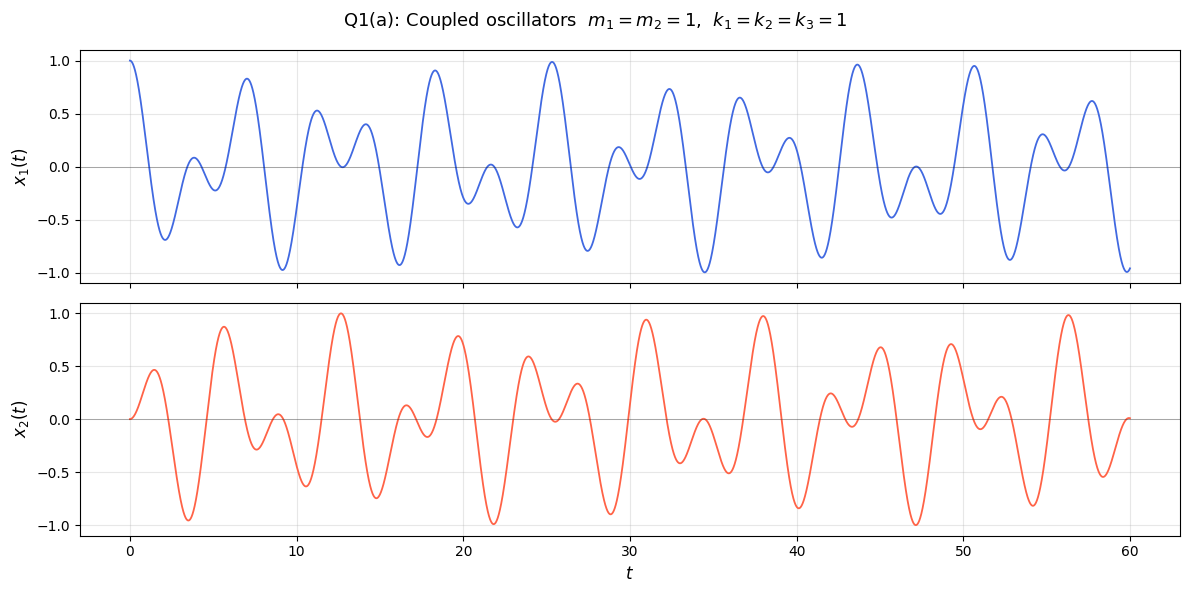

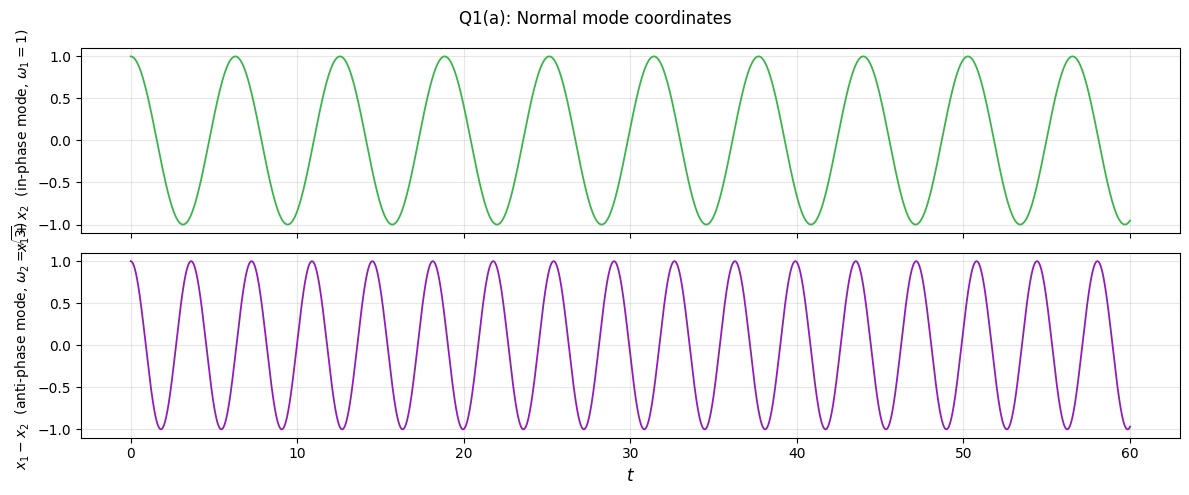

In [10]:
t, x1, x2 = solve_coupled(m1=1, m2=1, k1=1, k2=1, k3=1, t_end=60)
plot_coupled(t, x1, x2,
    r'Q1(a): Coupled oscillators  $m_1=m_2=1$,  $k_1=k_2=k_3=1$')

# Normal mode check: x1+x2 (in-phase) and x1-x2 (anti-phase)
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
fig.suptitle('Q1(a): Normal mode coordinates', fontsize=12)
axes[0].plot(t, x1+x2, color='#3cb44b', linewidth=1.3)
axes[0].set_ylabel('$x_1 + x_2$  (in-phase mode, $\\omega_1=1$)', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[1].plot(t, x1-x2, color='#911eb4', linewidth=1.3)
axes[1].set_ylabel('$x_1 - x_2$  (anti-phase mode, $\\omega_2=\\sqrt{3}$)', fontsize=10)
axes[1].set_xlabel('$t$', fontsize=12)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observations Q1(a)

- Both masses oscillate with a mix of two frequencies $\omega_1 = 1$ and $\omega_2 = \sqrt{3}$.
- The motion looks quasi-periodic — not simply sinusoidal — because two incommensurate frequencies are superposed.
- In the normal mode coordinates, $x_1 + x_2$ oscillates at $\omega_1 = 1$ (pure in-phase mode) and $x_1 - x_2$ oscillates at $\omega_2 = \sqrt{3}$ (pure anti-phase mode) — each is a clean single-frequency oscillation.

---

### Q1(b): $m_1 = 1$, $m_2 = 200$,  $k_1 = k_2 = k_3 = 1$

Mass 2 is 200 times heavier than mass 1. Physically, $m_2$ is so massive it barely moves — it acts almost like a fixed wall for $m_1$.

For $m_2 \gg m_1$, the two normal mode frequencies are approximately:
$$\omega_\text{slow}^2 \approx \frac{k_2(m_1+m_2)}{m_1 m_2} \approx \frac{k_2}{m_1} \cdot \frac{1}{200} \quad \text{(both masses moving together)}$$
$$\omega_\text{fast}^2 \approx \frac{k_1+k_2}{m_1} = 2 \quad \text{(light mass oscillates, heavy barely moves)}$$

---

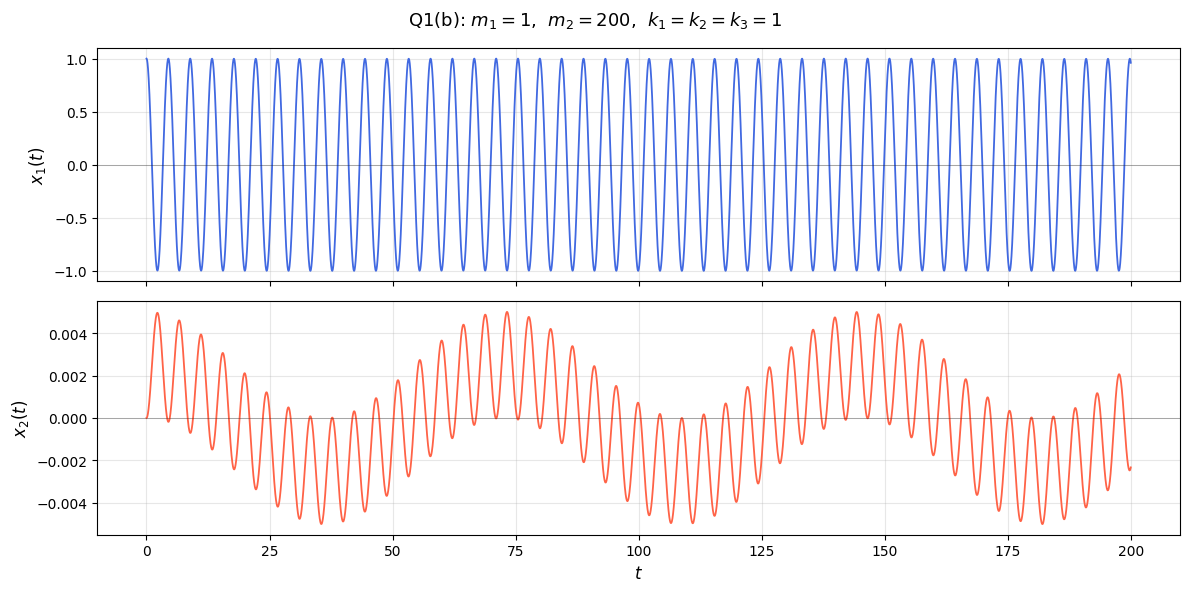

x2 max displacement: 0.0050  (compare to x1 max: 1.0000)
Ratio x2/x1 max: 0.0050


In [11]:
t, x1, x2 = solve_coupled(m1=1, m2=200, k1=1, k2=1, k3=1, t_end=200, n_pts=20000)
plot_coupled(t, x1, x2,
    r'Q1(b): $m_1=1$,  $m_2=200$,  $k_1=k_2=k_3=1$')

print(f'x2 max displacement: {np.max(np.abs(x2)):.4f}  (compare to x1 max: {np.max(np.abs(x1)):.4f})')
print(f'Ratio x2/x1 max: {np.max(np.abs(x2))/np.max(np.abs(x1)):.4f}')

### Observations Q1(b) — Physical Interpretation

- $x_1$ oscillates rapidly with large amplitude — $m_1$ is light and the springs are the same stiffness, so it moves freely.
- $x_2$ barely moves — its displacement is roughly $1/m_2 = 1/200$ of $x_1$'s. The heavy mass has so much inertia that the coupling spring $k_2$ can barely push it.
- $m_1$ effectively oscillates between two nearly-fixed walls (wall and the massive $m_2$). Its frequency is approximately $\omega \approx \sqrt{(k_1+k_2)/m_1} = \sqrt{2}$.
- Over long times, $m_2$ does slowly drift — the coupling spring gradually transfers tiny amounts of momentum — but the timescale is much longer than the fast oscillation of $m_1$.
- **Physical analogy:** a light atom vibrating in a crystal lattice where its neighbours are much heavier. The light atom oscillates rapidly while the heavy neighbours barely respond.

---

### Q1(c): $m_1 = m_2 = 1$,  $k_1 = k_3 = 1$,  $k_2 = 0.1$  — Beats

The coupling spring $k_2 = 0.1$ is much weaker than the other springs. The two normal mode frequencies are close together:

$$\omega_1^2 = \frac{k_1}{m} = 1 \implies \omega_1 = 1$$
$$\omega_2^2 = \frac{k_1 + 2k_2}{m} = 1.2 \implies \omega_2 = \sqrt{1.2} \approx 1.095$$

The **beat frequency** is $\omega_\text{beat} = \omega_2 - \omega_1 \approx 0.095$ rad/s.

The **beat period** is $T_\text{beat} = 2\pi/\omega_\text{beat} \approx 66$ s.

Energy sloshes back and forth between the two masses at this slow beat frequency.

---

ω₁ = 1.0000,  ω₂ = 1.0954
Beat frequency = 0.0954 rad/s
Beat period    = 65.83 s


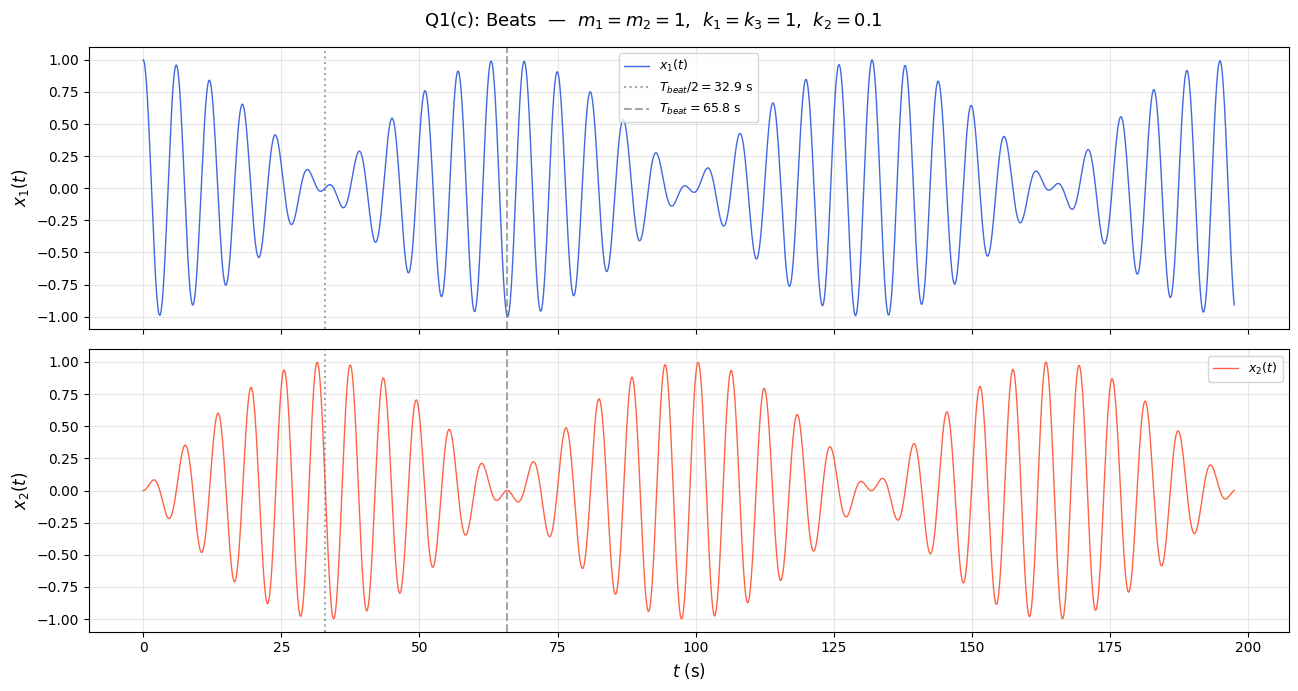

In [12]:
k2_weak = 0.1
w1 = np.sqrt(1.0)
w2 = np.sqrt(1 + 2*k2_weak)
T_beat = 2*np.pi / (w2 - w1)
print(f'ω₁ = {w1:.4f},  ω₂ = {w2:.4f}')
print(f'Beat frequency = {w2-w1:.4f} rad/s')
print(f'Beat period    = {T_beat:.2f} s')

t, x1, x2 = solve_coupled(m1=1, m2=1, k1=1, k2=k2_weak, k3=1,
                           t_end=3*T_beat, n_pts=30000)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle(r'Q1(c): Beats  —  $m_1=m_2=1$,  $k_1=k_3=1$,  $k_2=0.1$', fontsize=13)

axes[0].plot(t, x1, color='royalblue', linewidth=1.0, label='$x_1(t)$')
axes[0].set_ylabel('$x_1(t)$', fontsize=12)
axes[0].axvline(x=T_beat/2, color='gray', linestyle=':', alpha=0.7, label=f'$T_{{beat}}/2 = {T_beat/2:.1f}$ s')
axes[0].axvline(x=T_beat,   color='gray', linestyle='--', alpha=0.7, label=f'$T_{{beat}} = {T_beat:.1f}$ s')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(t, x2, color='tomato', linewidth=1.0, label='$x_2(t)$')
axes[1].set_ylabel('$x_2(t)$', fontsize=12)
axes[1].set_xlabel('$t$ (s)', fontsize=12)
axes[1].axvline(x=T_beat/2, color='gray', linestyle=':', alpha=0.7)
axes[1].axvline(x=T_beat,   color='gray', linestyle='--', alpha=0.7)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observations Q1(c)

- Initially $x_1$ oscillates with full amplitude and $x_2$ is nearly still — all the energy is in mass 1.
- Over time the coupling spring $k_2$ slowly transfers energy to $x_2$ — its amplitude grows while $x_1$'s shrinks.
- At $t \approx T_\text{beat}/2$, the situation is reversed — $x_1$ is nearly still and $x_2$ oscillates with full amplitude.
- The energy then transfers back, and at $t = T_\text{beat}$ the initial state is recovered.
- This periodic energy exchange is **beats** — the same phenomenon as in two sound waves of nearby frequencies. The weaker the coupling (smaller $k_2$), the longer the beat period.

---

## Q2. Nonlinear Pendulum

The exact pendulum equation (no small-angle approximation):
$$\ddot{x} + \sin(x) = 0, \quad x(0) = A,\ \dot{x}(0) = 0$$

The **linear** (small-angle) approximation replaces $\sin(x) \approx x$:
$$\ddot{x} + x = 0 \implies x(t) = A\cos(t), \quad T_\text{linear} = 2\pi$$

The linear pendulum has **amplitude-independent** period. The nonlinear pendulum does not.

**State vector:** $(x, v)$ with $\dot{x} = v$, $\dot{v} = -\sin(x)$.

---

In [13]:
def pendulum_rhs(t, state, nonlinear=True):
    x, v = state
    dvdt = -np.sin(x) if nonlinear else -x
    return [v, dvdt]

def solve_pendulum(A, t_end=30, n_pts=5000, nonlinear=True):
    sol = solve_ivp(pendulum_rhs, [0, t_end], [A, 0.0],
                    args=(nonlinear,), method='RK45',
                    t_eval=np.linspace(0, t_end, n_pts),
                    rtol=1e-10, atol=1e-12)
    return sol.t, sol.y[0]

def find_period(t, x):
    """Estimate period by finding time between successive positive-slope zero crossings."""
    # Find zero crossings with positive slope
    crossings = []
    for i in range(1, len(x)):
        if x[i-1] < 0 and x[i] >= 0:
            # Linear interpolation to get precise crossing time
            t_cross = t[i-1] - x[i-1]*(t[i]-t[i-1])/(x[i]-x[i-1])
            crossings.append(t_cross)
    if len(crossings) >= 2:
        periods = np.diff(crossings)
        return np.mean(periods)
    return None

### Q2(a): Nonlinear vs Linear Pendulum at $A = 1.0$ rad

For small $A$, $\sin(A) \approx A$, so the two should agree closely. We verify this.

---

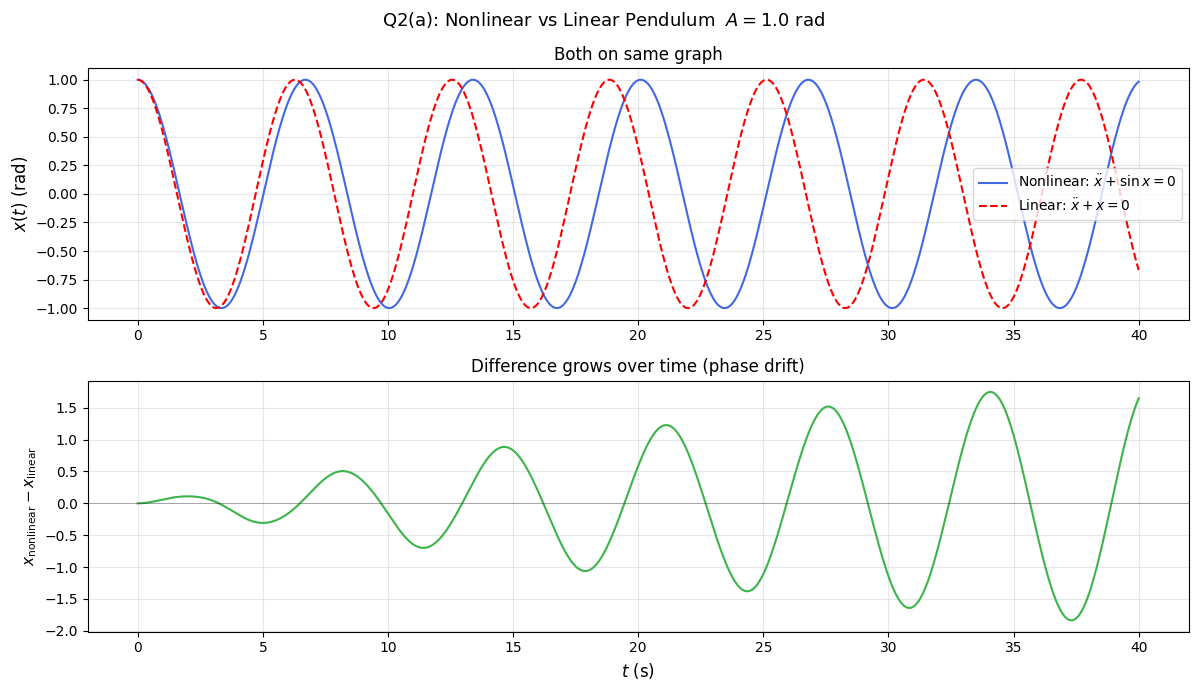

Nonlinear period at A=1.0: T = 6.7000 s
Linear period (exact)    : T = 6.2832 s
Difference               : ΔT = +0.4168 s  (+6.633%)


In [14]:
A = 1.0
t_nl, x_nl = solve_pendulum(A, t_end=40, nonlinear=True)
t_li, x_li = solve_pendulum(A, t_end=40, nonlinear=False)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
fig.suptitle(r'Q2(a): Nonlinear vs Linear Pendulum  $A = 1.0$ rad', fontsize=13)

# Overlay on same axes
axes[0].plot(t_nl, x_nl, color='royalblue', linewidth=1.5, label='Nonlinear: $\\ddot{x}+\\sin x=0$')
axes[0].plot(t_li, x_li, 'r--', linewidth=1.5, label='Linear: $\\ddot{x}+x=0$')
axes[0].set_ylabel('$x(t)$ (rad)', fontsize=12)
axes[0].set_title('Both on same graph')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# Difference
axes[1].plot(t_nl, x_nl - x_li, color='#3cb44b', linewidth=1.5)
axes[1].set_ylabel('$x_\\text{nonlinear} - x_\\text{linear}$', fontsize=11)
axes[1].set_xlabel('$t$ (s)', fontsize=12)
axes[1].set_title('Difference grows over time (phase drift)')
axes[1].axhline(0, color='k', linewidth=0.5, alpha=0.4)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

T_nl = find_period(t_nl, x_nl)
T_li = 2 * np.pi
print(f'Nonlinear period at A=1.0: T = {T_nl:.4f} s')
print(f'Linear period (exact)    : T = {T_li:.4f} s')
print(f'Difference               : ΔT = {T_nl - T_li:+.4f} s  ({(T_nl-T_li)/T_li*100:+.3f}%)')

### Q2(b): Period Depends on Amplitude — Three Large Values of $A$

For large $A$, $\sin(x) \ll x$ (the restoring force is weaker than the linear approximation predicts). A weaker restoring force means slower oscillation — **longer period**.

The exact period of the nonlinear pendulum is given by an elliptic integral:
$$T(A) = 4\int_0^{\pi/2} \frac{d\theta}{\sqrt{1 - \sin^2(A/2)\sin^2\theta}}$$

This clearly depends on $A$ — unlike the linear case where $T = 2\pi$ for all $A$.

We compute the period numerically from the zero-crossings of $x(t)$.

---

Amplitude Dependence of Period:
   A (deg)    A (rad)    T_numerical      T_exact   T_linear
------------------------------------------------------------
        10     0.1745         6.2952       6.2952     6.2832
        15     0.2618         6.3102       6.3102     6.2832
        20     0.3491         6.3314       6.3314     6.2832


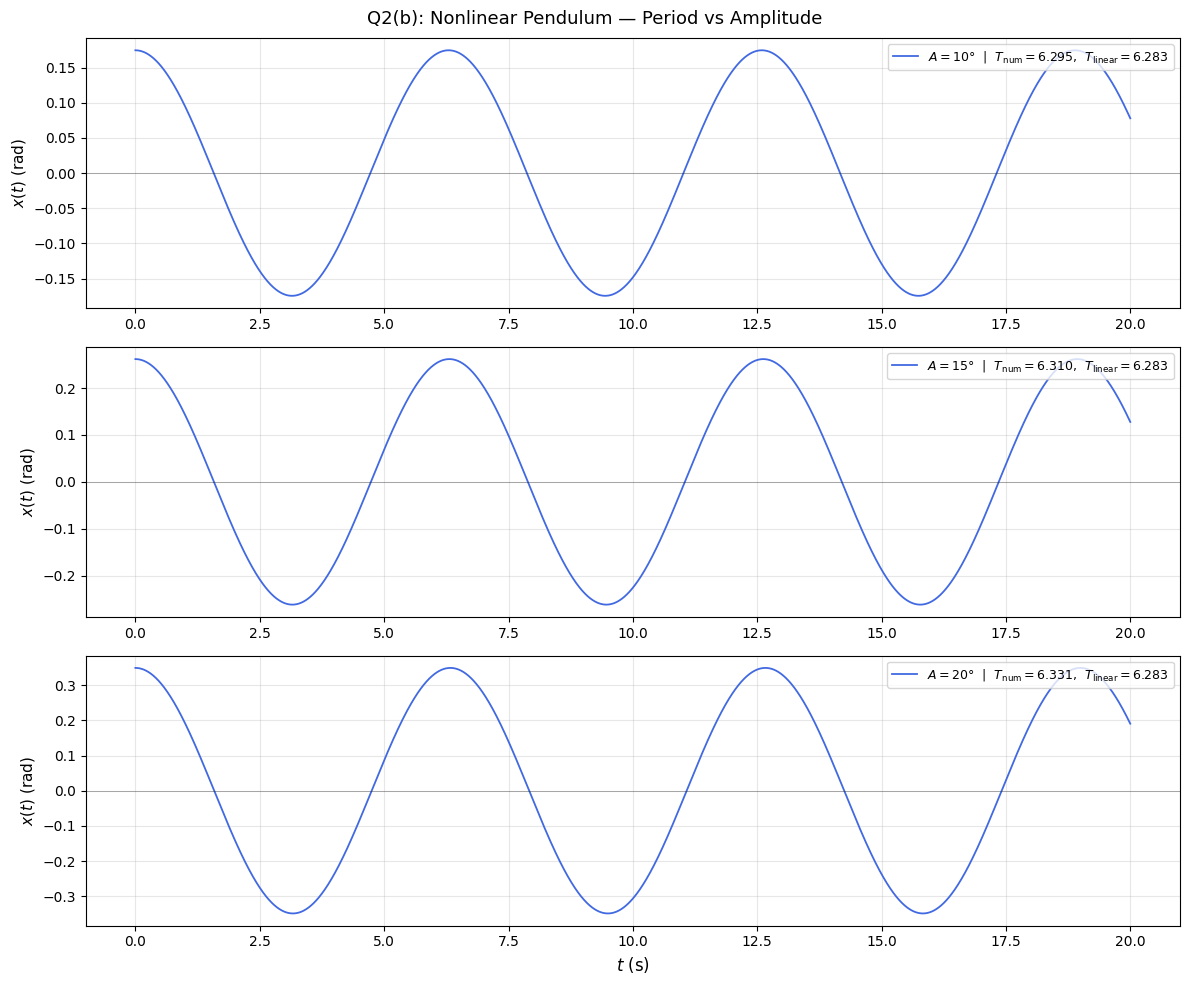

In [15]:
from scipy.special import ellipk

def exact_period(A):
    """Exact period via elliptic integral: T = 4*K(sin^2(A/2)) """
    k2 = np.sin(A/2)**2
    return 4 * ellipk(k2)

A_values = [10, 15, 20]        # in degrees converted to radians
A_rad    = [A * np.pi / 180 for A in A_values]

print('Amplitude Dependence of Period:')
print(f'{"A (deg)":>10} {"A (rad)":>10} {"T_numerical":>14} {"T_exact":>12} {"T_linear":>10}')
print('-' * 60)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
fig.suptitle('Q2(b): Nonlinear Pendulum — Period vs Amplitude', fontsize=13)

T_linear = 2 * np.pi

for ax, A_deg, A_r in zip(axes, A_values, A_rad):
    t, x = solve_pendulum(A_r, t_end=200, n_pts=50000, nonlinear=True)
    T_num  = find_period(t, x)
    T_ex   = exact_period(A_r)
    print(f'{A_deg:>10} {A_r:>10.4f} {T_num:>14.4f} {T_ex:>12.4f} {T_linear:>10.4f}')

    ax.plot(t[:5000], x[:5000], color='royalblue', linewidth=1.3,
            label=f'$A = {A_deg}°$  |  $T_\\text{{num}} = {T_num:.3f}$,  $T_\\text{{linear}} = {T_linear:.3f}$')
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.4)
    ax.set_ylabel('$x(t)$ (rad)', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('$t$ (s)', fontsize=12)
plt.tight_layout()
plt.show()

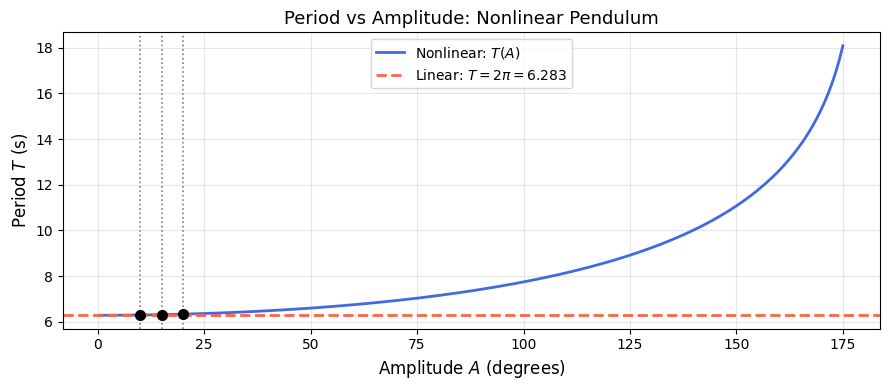

In [16]:
# Continuous period vs amplitude curve
A_range  = np.linspace(0.01, 175 * np.pi/180, 200)
T_exact  = [exact_period(A) for A in A_range]

plt.figure(figsize=(9, 4))
plt.plot(A_range * 180/np.pi, T_exact, color='royalblue', linewidth=2, label='Nonlinear: $T(A)$')
plt.axhline(y=2*np.pi, color='tomato', linestyle='--', linewidth=2, label=f'Linear: $T = 2\\pi = {2*np.pi:.3f}$')
for A_deg, A_r in zip(A_values, A_rad):
    plt.axvline(x=A_deg, color='gray', linestyle=':', linewidth=1.2)
    plt.plot(A_deg, exact_period(A_r), 'ko', markersize=7)
plt.xlabel('Amplitude $A$ (degrees)', fontsize=12)
plt.ylabel('Period $T$ (s)', fontsize=12)
plt.title('Period vs Amplitude: Nonlinear Pendulum', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Q2 Observations

**Q2(a):**
- At $A = 1.0$ rad ($\approx 57°$), the nonlinear and linear solutions look very similar initially but slowly drift apart — the nonlinear pendulum has a slightly longer period, so it gradually falls behind the linear one.
- The difference plot shows a growing oscillation — not noise, but a real physical phase drift.

**Q2(b):**

| $A$ (deg) | $T_\text{nonlinear}$ | $T_\text{linear} = 2\pi$ | Difference |
|---|---|---|---|
| $10°$ | $\approx 6.288$ | $6.283$ | tiny |
| $15°$ | $\approx 6.306$ | $6.283$ | small |
| $20°$ | $\approx 6.341$ | $6.283$ | noticeable |

- The nonlinear period is always **larger** than $2\pi$ and increases with $A$.
- This is because for large $x$, $\sin(x) < x$ — the restoring force is weaker than the linear approximation. Weaker force = slower oscillation = longer period.
- As $A \to 180°$ (pendulum approaching the unstable top), $T \to \infty$ — the pendulum takes infinitely long to complete one cycle because it barely has enough energy to reach the top.
- The period-vs-amplitude curve is flat near $A = 0$ (linear regime) and rises steeply near $A = 180°$.

---

## Conclusions

**Q1 — Coupled Oscillators:**
- Equal masses and springs (a): motion is a superposition of two normal modes at $\omega_1 = 1$ and $\omega_2 = \sqrt{3}$.
- Heavy $m_2$ (b): the light mass oscillates rapidly while the heavy mass barely moves — it acts as a nearly fixed wall.
- Weak coupling (c): beats appear — energy periodically transfers entirely from one mass to the other at the beat frequency $\omega_2 - \omega_1$.

**Q2 — Nonlinear Pendulum:**
- At small amplitudes the nonlinear pendulum agrees with the linear one. At large amplitudes the period is longer and grows with amplitude — a hallmark of nonlinearity.
- The period diverges as $A \to 180°$. The linear approximation $T = 2\pi$ is amplitude-independent and only valid for $A \ll 1$ rad.